In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import seaborn as sns
import matplotlib.pyplot as plt

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [2]:
sns.set_theme(style="whitegrid")

In [3]:
np.random.seed(42)

x = np.linspace(0, 10, 100)

y = 1 + 2 * x + np.random.normal(0, 2, size=len(x))

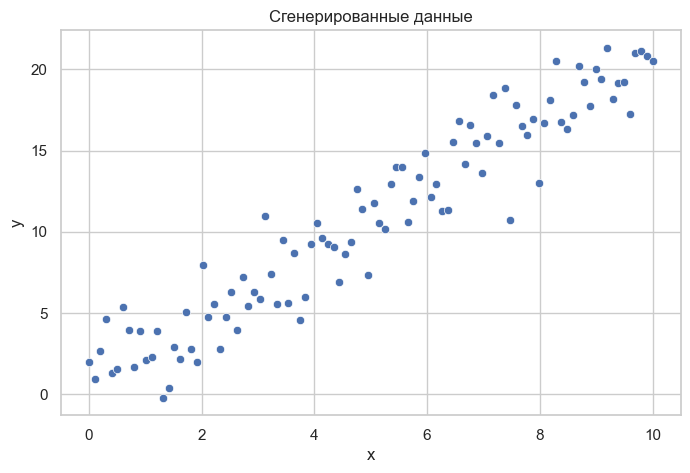

In [4]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x=x, y=y)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Сгенерированные данные")

plt.show()

In [5]:
with pm.Model() as linear_model:

    alpha = pm.Normal("alpha", mu=0, sigma=10)

    beta = pm.Normal("beta", mu=0, sigma=10)

    sigma = pm.HalfNormal("sigma", sigma=5)

    mu = alpha + beta * x

    y_obs = pm.Normal(
        "y_obs",
        mu=mu,
        sigma=sigma,
        observed=y
    )

    trace = pm.sample(
        draws=2000,
        tune=1000,
        target_accept=0.95,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 300 seconds.


In [6]:
az.summary(trace, var_names=["alpha", "beta", "sigma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.661,0.369,-0.033,1.348,0.007,0.005,2884.0,3204.0,1.0
beta,2.026,0.064,1.912,2.153,0.001,0.001,2832.0,3296.0,1.0
sigma,1.852,0.138,1.597,2.107,0.002,0.002,4026.0,3796.0,1.0


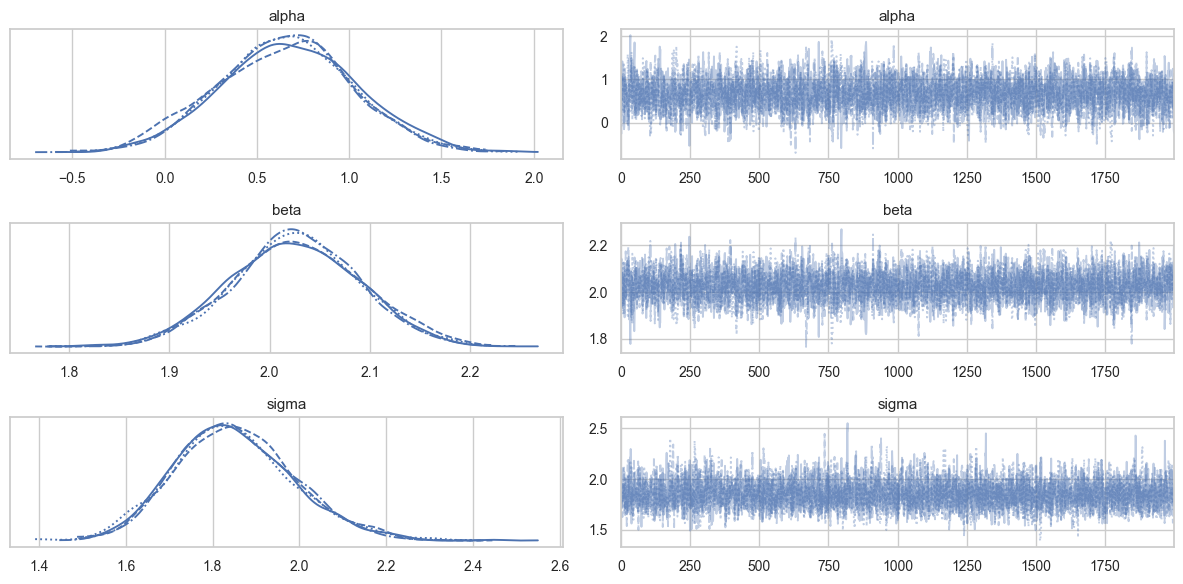

In [7]:
az.plot_trace(trace, var_names=["alpha", "beta", "sigma"])
plt.tight_layout();

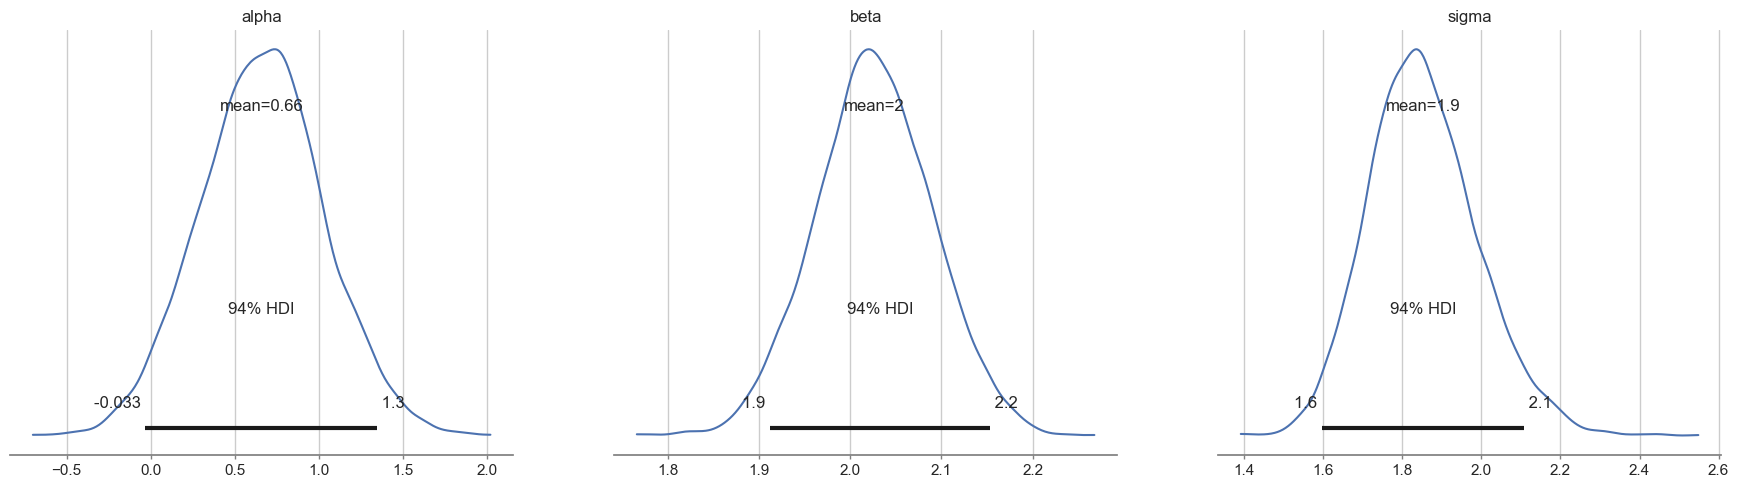

In [8]:
az.plot_posterior(trace, var_names=["alpha", "beta", "sigma"]);

In [9]:
alpha_mean = trace.posterior["alpha"].mean().item()
beta_mean = trace.posterior["beta"].mean().item()

y_pred = alpha_mean + beta_mean * x

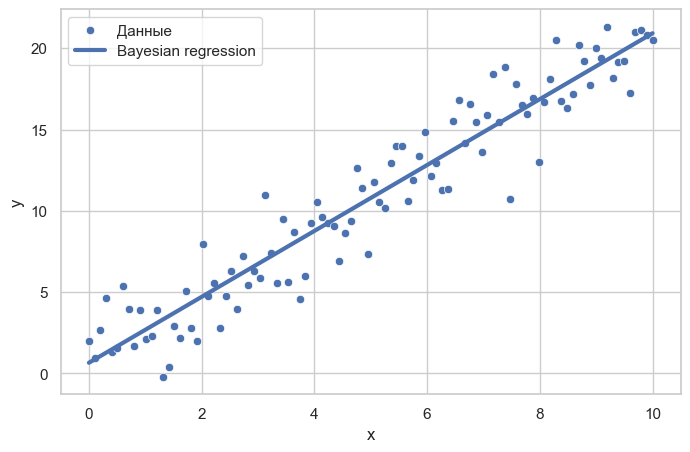

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x=x, y=y, label="Данные")

plt.plot(x, y_pred, linewidth=3, label="Bayesian regression")

plt.xlabel("x")
plt.ylabel("y")

plt.legend();

In [11]:
posterior = trace.posterior

alpha_samples = posterior["alpha"].stack(sample=("chain", "draw")).values
beta_samples = posterior["beta"].stack(sample=("chain", "draw")).values

x_grid = np.linspace(x.min(), x.max(), 100)

y_lines = alpha_samples[:, None] + beta_samples[:, None] * x_grid[None, :]
y_mean = y_lines.mean(axis=0)
y_hdi = az.hdi(y_lines, hdi_prob=0.94)

C:\Users\Admin\AppData\Local\Temp\ipykernel_21144\2306522110.py:10: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  y_hdi = az.hdi(y_lines, hdi_prob=0.94)


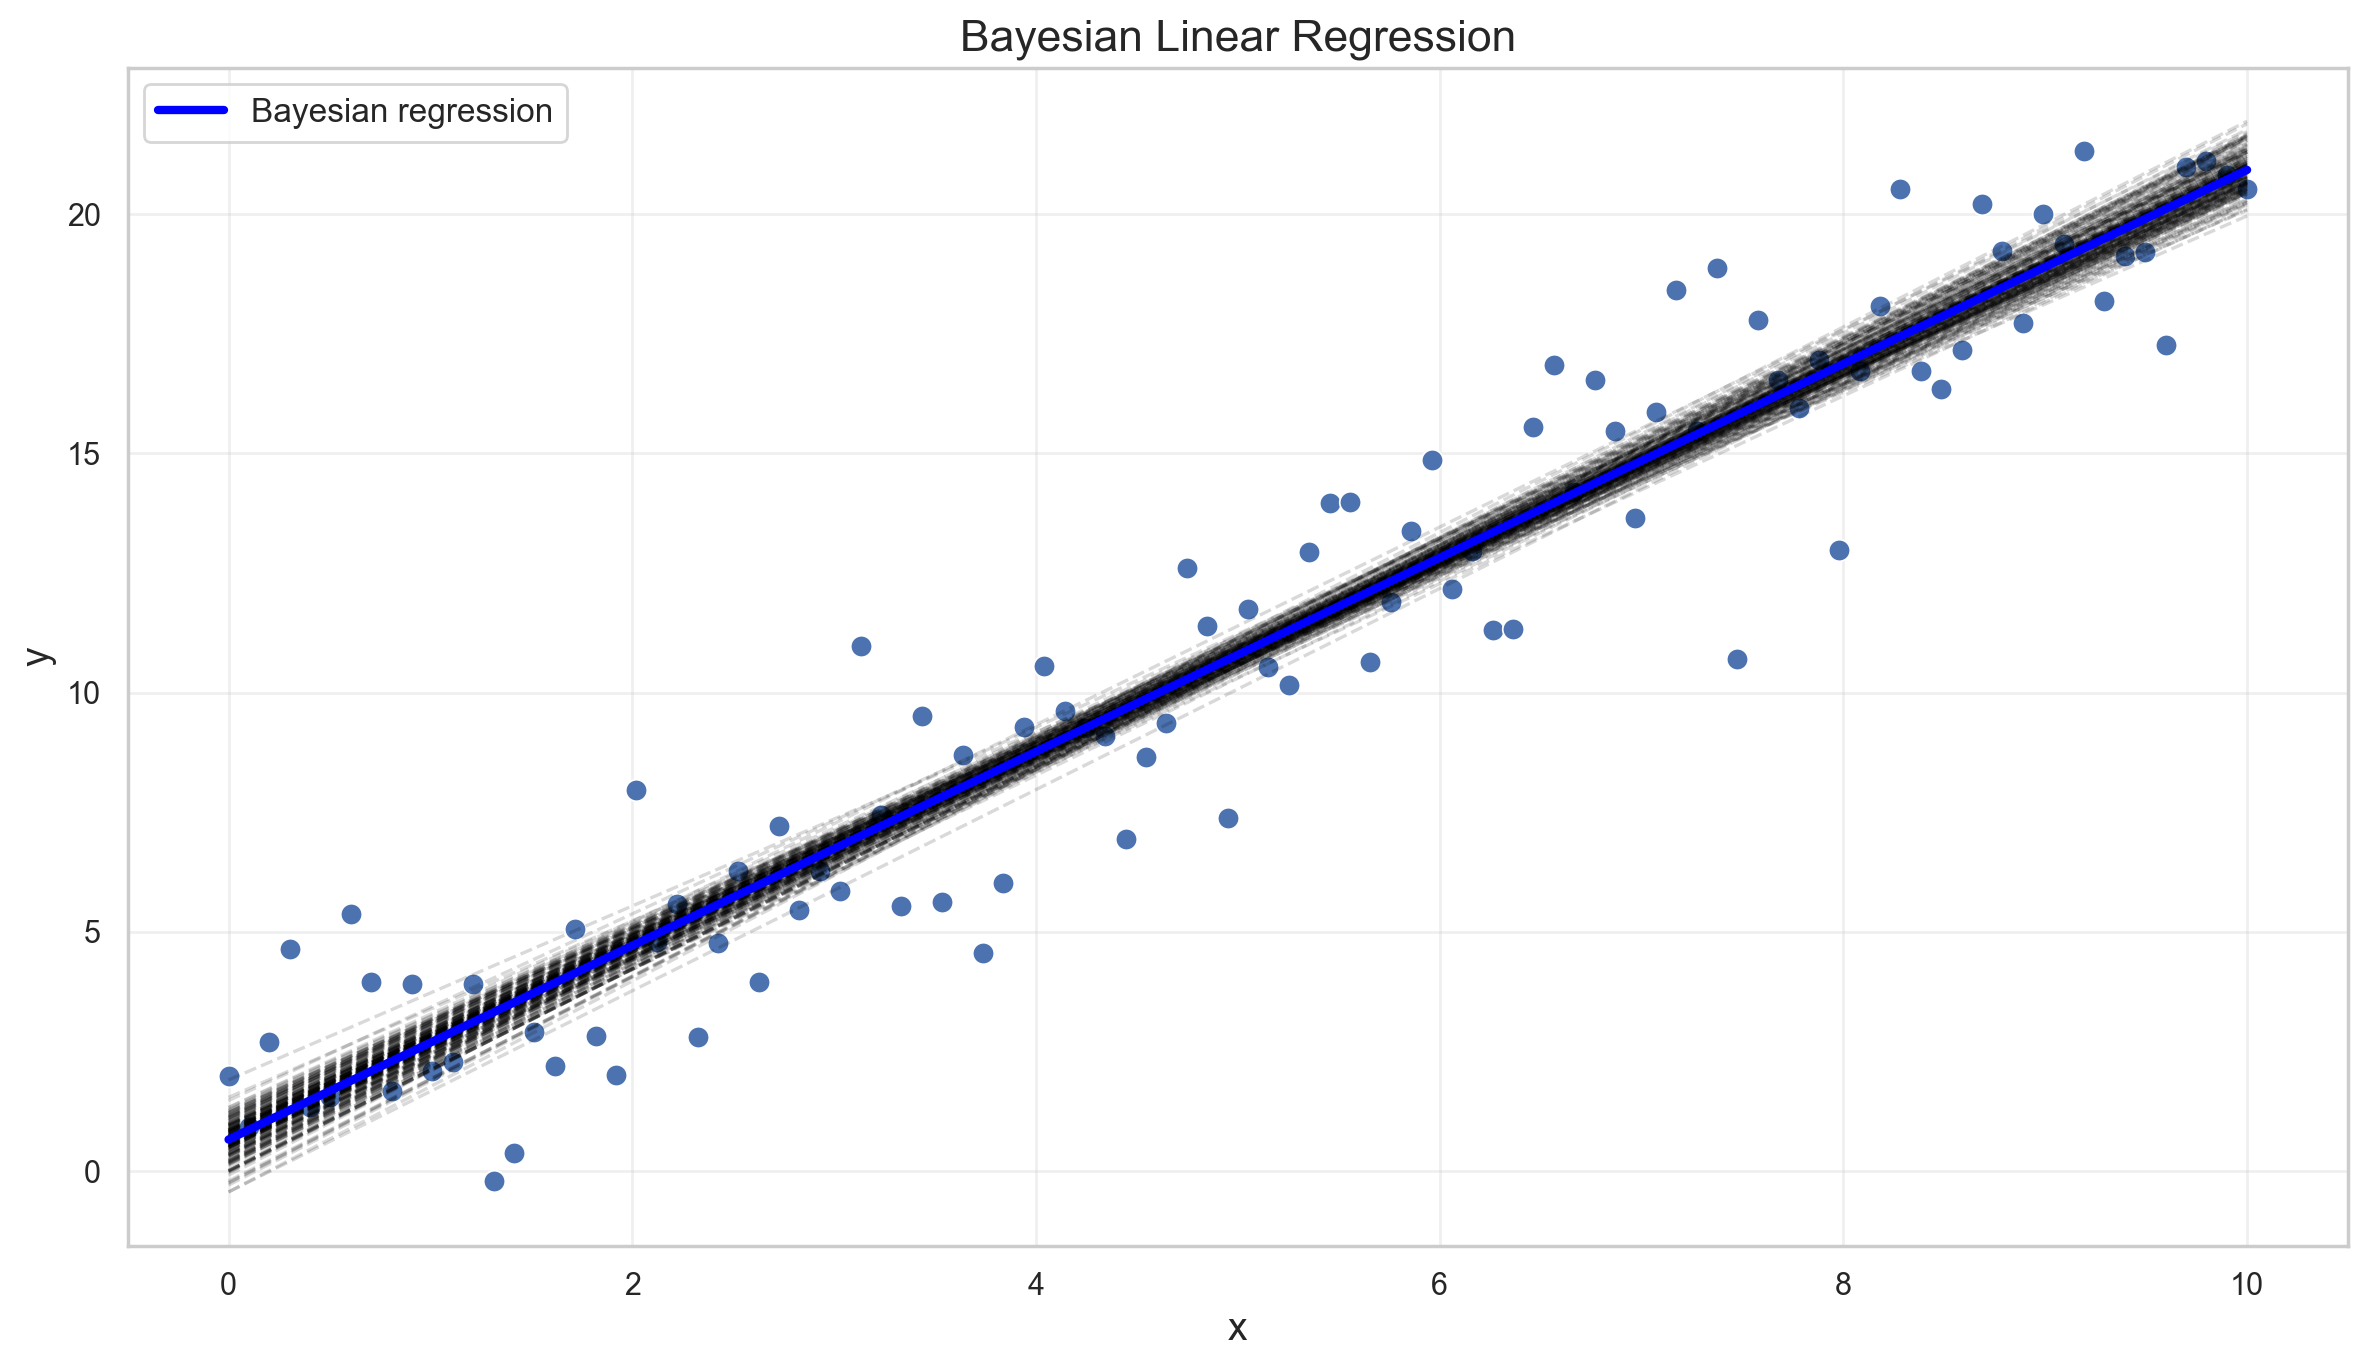

In [12]:
plt.figure(figsize=(12, 7), dpi=200)

idx = np.random.choice(
    len(alpha_samples),
    size=200,
    replace=False
)

sns.scatterplot(x=x, y=y, s=60)

for i in idx:
    y_sample = alpha_samples[i] + beta_samples[i] * x_grid
    plt.plot(
        x_grid,
        y_sample,
        linestyle="--",
        linewidth=1.2,
        alpha=0.15,
        color="black"
    )

plt.plot(
    x_grid,
    y_mean,
    color="blue",
    linewidth=3,
    label="Bayesian regression"
)

plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14)
plt.title("Bayesian Linear Regression", fontsize=16)

plt.grid(alpha=0.3)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [13]:
posterior = trace.posterior

alpha_samples = posterior["alpha"].stack(sample=("chain", "draw")).values
beta_samples = posterior["beta"].stack(sample=("chain", "draw")).values

x_grid = np.linspace(x.min(), x.max(), 100)

y_lines = alpha_samples[:, None] + beta_samples[:, None] * x_grid[None, :]
y_mean = y_lines.mean(axis=0)
y_hdi = az.hdi(y_lines, hdi_prob=0.94)

C:\Users\Admin\AppData\Local\Temp\ipykernel_21144\2306522110.py:10: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  y_hdi = az.hdi(y_lines, hdi_prob=0.94)


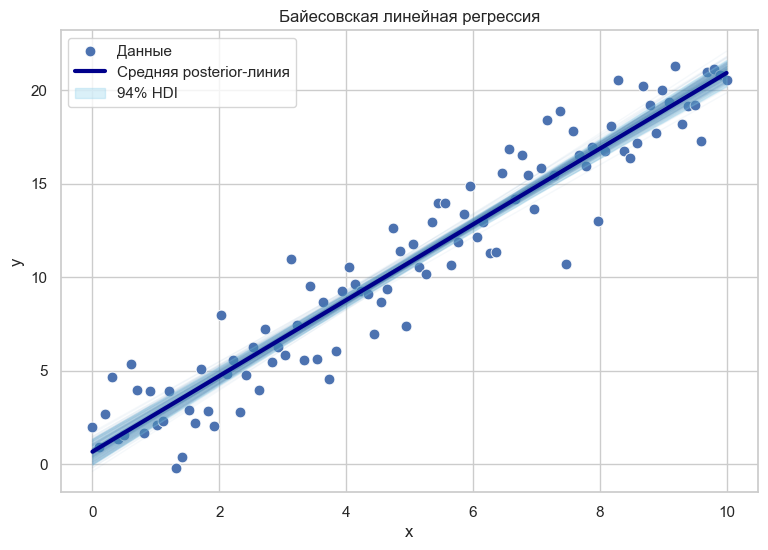

In [14]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=x,
    y=y,
    s=60,
    label="Данные"
)

idx = np.random.choice(
    len(alpha_samples),
    size=200,
    replace=False
)

for i in idx:
    plt.plot(
        x_grid,
        y_lines[i],
        color="steelblue",
        alpha=0.05,
        linewidth=1
    )

plt.plot(
    x_grid,
    y_mean,
    color="darkblue",
    linewidth=3,
    label="Средняя posterior-линия"
)

plt.fill_between(
    x_grid,
    y_hdi[:, 0],
    y_hdi[:, 1],
    color="skyblue",
    alpha=0.3,
    label="94% HDI"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Байесовская линейная регрессия")
plt.legend();